In [76]:
from os import listdir, makedirs
from os.path import isfile, isdir, join

import numpy as np
import pandas as pd

def get_aia_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%dT%H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%dT%H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%dT%H:%M:%S')
    return df

def get_goes_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter=',', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%d %H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%d %H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%d %H:%M:%S')
    return df

def fix_timestamps(ds, format=None):
    if format is None:
        ds_fixed = pd.to_datetime(ds, format="%Y%m%d_%H%M%S")
    else:
        ds_fixed = pd.to_datetime(ds, format=format)
    return ds_fixed

def remove_duplicates_from_goes_flares(goes_df):
    # remove all totally duplicated rows from goes df
    duplicates = goes_df.duplicated(subset=['start_time', 'end_time', 'peak_time', 'noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = goes_df[duplicates]
    goes_df = goes_df[~duplicates]
    return goes_df, duplicated


def remove_duplicates_from_aia_flares(aia_df):
    duplicates = aia_df.duplicated(subset=['start_time', 'end_time', 'peak_time','noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = aia_df[duplicates]
    aia_df = aia_df[~duplicates]
    return aia_df, duplicated

def get_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter=',',
                     parse_dates=['start_time', 'end_time', 'peak_time', 'peak_time_aia', 'peak_time_goes'])
    new_columns = df.columns.values
    new_columns[0] = 'flare_id'
    df.columns = new_columns
    df = df.set_index('flare_id')

    # return fix_noaa_ar_numbers( pd.read_csv(file_path, delimiter='\t', parse_dates=True) )
    df = fix_end_times(fix_peak_times(fix_flare_locations(fix_noaa_ar_numbers(df))))
    # df = df[ df['goes_class'] > 'C9.9' ]
    return df

def fix_peak_times(df):
    """ Gets the flare dataframe and consolidates the peaktimes from aia and goes using the following strategy
        if the is a valid peak time from goes, it uses that. If not it uses the aia one"""

    # for each null (nan) peak time, get the peak time from goes
    df.loc[pd.isnull(df['peak_time']), 'peak_time'] = df.loc[pd.isnull(df['peak_time']), 'peak_time_goes']
    
    # for each null (nan) peak time, get the peak time from aia
    df.loc[pd.isnull(df['peak_time']), 'peak_time'] = df.loc[pd.isnull(df['peak_time']), 'peak_time_aia']

    return df

def fix_end_times(df):
    """ Gets the flare dataframe and consolidates the end times from aia and goes using the following strategy
        if the is a valid peak time from goes, it uses that. If not it uses the aia one"""

    # for each null (nan) peak time, get the peak time from goes
    df.loc[pd.isnull(df['end_time']), 'end_time'] = df.loc[pd.isnull(df['end_time']), 'end_time_y']
    
    # for each null (nan) peak time, get the peak time from aia
    df.loc[pd.isnull(df['end_time']), 'end_time'] = df.loc[pd.isnull(df['end_time']), 'end_time_x']


    return df

def fix_noaa_ar_numbers(df):
    """ Gets the flare dataframe and consolidates the noaa ar numbers from aia and goes using the following strategy
        if the is a valid goes active region, that is not 0, it uses that. If not it uses a valid aia number"""

    # set goes noaa numbers as primary source
    df['noaa_active_region'] = df['noaa_active_region_goes']
    # if noaa ar no from goes is zero, set it to NaN
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan

    # for each null (nan) noaa ar number, get the ar number from aia
    df.loc[pd.isnull(df['noaa_active_region']), 'noaa_active_region'] = \
        df.loc[pd.isnull(df['noaa_active_region']), 'noaa_active_region_aia']
    # for each noaa ar number that is still zero, set it to nan
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan

    # print len(df['noaa_active_region'].unique())
    return df

def fix_flare_locations(df):
    """ Gets the flare dataframe and consolidates the flare locations from aia and goes using the following strategy
        if there is a valid aia location, that is not NaN, it uses that. If not it uses the goes location if valid"""

    # set goes location as primary source
    df['fl_location'] = df['goes_location']

    # for each goes location that is still invalid --(0, 0), set it to nan
    df.loc[df['fl_location'] == '(0, 0)', 'fl_location'] = np.nan

    # create two new columns fl_lat and fl_lon for latitude and longitude
    df = df.reindex(columns=np.append(df.columns.values, ['fl_lat', 'fl_lon']))
    # extract the locations from either aia or goes location strings
    df = df.apply(reformat_locations, axis=1)

    # print df.to_csv('flares_flares.csv')
    return df


def reformat_locations(row):
    gloc = row['fl_location']
    # print pd.isnull(gloc),gloc
    if pd.isnull(gloc):
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    elif gloc.startswith('POINT'):
        row['fl_lon'] = float(gloc.strip('POINT(').strip(')').split(' ')[0])
        row['fl_lat'] = float(gloc.strip('POINT(').strip(')').split(' ')[1])
    elif gloc.startswith('('):
        row['fl_lon'] = float(gloc.strip('(').strip(')').split(', ')[0])
        row['fl_lat'] = float(gloc.strip('(').strip(')').split(', ')[1])
    else:
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    return row


def transform_fl_lat_lon(fdf):
    lat = fdf['fl_lat'] 
    lon = fdf['fl_lon']
    fdf['y'] = np.sin(np.deg2rad(lat))
    fdf['x'] = np.sin(np.deg2rad(lon)) * np.cos(np.deg2rad(lat))
    return fdf

import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
def append_hpc_coord(fdf):
    fdf['x_hpc'] = fdf.apply(xcoord_transformer, axis=1) # x coordinates of hpc
    fdf['y_hpc'] = fdf.apply(ycoord_transformer, axis=1) # y coordinates of hpc
    return fdf

def xcoord_transformer(x):
    lon = x['fl_lon']
    lat = x['fl_lat']
    edate = x['event_date']
    c = SkyCoord(lon*u.deg, lat*u.deg, frame=frames.HeliographicStonyhurst, obstime=edate)
    c_hpc = c.transform_to(frames.Helioprojective)
    return c_hpc.Tx.arcsec #tx

def ycoord_transformer(x):
    lon = x['fl_lon']
    lat = x['fl_lat']
    edate = x['event_date']
    c = SkyCoord(lon*u.deg, lat*u.deg, frame=frames.HeliographicStonyhurst, obstime=edate)
    c_hpc = c.transform_to(frames.Helioprojective)
    return c_hpc.Ty.arcsec #Ty



In [78]:

goes_flare_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/goes_fl_wloc.csv'
goes_fl = get_goes_flare_dataframe(goes_flare_path)
goes_fl = append_hpc_coord(goes_fl)

print(goes_fl.shape)
goes_fl.head()

(12022, 16)


,Unnamed: 0,end_time,event_date,goes_class,goes_location,noaa_active_region,peak_time,start_time,fl_location,fl_lat,fl_lon,y,x,centroids,x_hpc,y_hpc
0,0,2010-05-01 01:43:00,2010-05-01,C5.7,"(-73, 23)",11067,2010-05-01 01:39:00,2010-05-01 01:34:00,"(-73, 23)",23.0,-73.000000,0.390731,-0.880283,"(-81.6429165159173, 23.0)",-838.861628,390.088856
1,1,2010-05-01 05:31:00,2010-05-01,B1.6,"(0, 0)",11064,2010-05-01 05:27:00,2010-05-01 05:23:00,"(-24.824108682811833, 15.0)",15.0,-24.824109,0.258819,-0.405529,"(-24.824108682811833, 15.0)",-387.550293,307.903571
2,2,2010-05-01 09:59:00,2010-05-01,B1.0,"(0, 0)",11067,2010-05-01 09:52:00,2010-05-01 09:48:00,"(-76.91981049565581, 23.0)",23.0,-76.919810,0.390731,-0.896622,"(-76.91981049565581, 23.0)",-854.191844,385.746557
3,3,2010-05-02 06:18:00,2010-05-02,B2.9,"(0, 0)",11067,2010-05-02 06:09:00,2010-05-02 06:03:00,"(-65.26054066470603, 23.0)",23.0,-65.260541,0.390731,-0.836021,"(-65.26054066470603, 23.0)",-796.907609,397.689140
4,4,2010-05-02 10:15:00,2010-05-02,B3.8,"(0, 0)",11067,2010-05-02 10:09:00,2010-05-02 10:02:00,"(-62.96125984348338, 23.0)",23.0,-62.961260,0.390731,-0.819893,"(-62.96125984348338, 23.0)",-781.654041,400.009584


In [77]:

# goes_flare_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/goes_fl_wloc.csv'
# goes_fl = get_goes_flare_dataframe(goes_flare_path)
# # goes_fl = append_hpc_coord(goes_fl)

# print (goes_fl.shape)
# goes_fl.head()

In [370]:

# THRESHOLD -->  1 arcsec 0.725 mega meters (250 arcsec)


In [79]:
goes_fl.shape[0]

12022

In [80]:
aia_flare_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/aiaFlares_automated_all.csv'
aia_fl = get_aia_flare_dataframe(aia_flare_path)
aia_fl['fl_location'] = aia_fl['goes_location'] 
aia_fl = aia_fl.apply(reformat_locations, axis=1)
# aia_fl = append_hpc_coord(aia_fl)
ssw = aia_fl[aia_fl['frm_name'] == 'SSW Latest Events']
fd = aia_fl[aia_fl['frm_name'] == 'Flare Detective - Trigger Module']

In [81]:
print(ssw.shape[0])
ssw.head(2)

13546


,event_date,start_time,end_time,goes_class,goes_location,noaa_active_region,peak_time,frm_name,fl_peakflux,fl_peakfluxunit,fl_location,fl_lon,fl_lat
0,2010-05-01,2010-05-01 01:34:00,2010-05-01 01:43:00,C5.7,POINT(-80.9999999999999 24),0.0,2010-05-01 01:39:00,SSW Latest Events,NaN,NaN,POINT(-80.9999999999999 24),-81.0,24.0
1,2010-05-01,2010-05-01 05:23:00,2010-05-01 05:31:00,B1.6,POINT(-74.9999999999999 22),0.0,2010-05-01 05:27:00,SSW Latest Events,NaN,NaN,POINT(-74.9999999999999 22),-75.0,22.0


In [82]:
print(fd.shape[0])
fd.head(2)

91879


,event_date,start_time,end_time,goes_class,goes_location,noaa_active_region,peak_time,frm_name,fl_peakflux,fl_peakfluxunit,fl_location,fl_lon,fl_lat
74,2010-06-11,2010-06-11 20:27:24,2010-06-11 21:02:48,NaN,POINT(47.885992 21.799763),NaN,2010-06-11 20:37:36,Flare Detective - Trigger Module,473.096,erg/cm/cm/s,POINT(47.885992 21.799763),47.885992,21.799763
75,2010-06-11,2010-06-11 20:27:26,2010-06-12 14:31:26,NaN,POINT(47.885993 21.799765),NaN,2010-06-12 01:00:14,Flare Detective - Trigger Module,900.444,erg/cm/cm/s,POINT(47.885993 21.799765),47.885993,21.799765


In [83]:
def locations_within_distance(row):
    """
    Helper lambda function for validate_locations
    :param row: a row in joined flare dataframe
    :return: True if the distance is within 15 degrees based on L2 distance
    """
    aia_loc = row['goes_location_x']
    aia_lon = row['fl_lon_aia']
    aia_lat = row['fl_lat_aia']
    
    goes_lon = row['fl_lon_goes']
    goes_lat = row['fl_lat_goes']
    
    goes_loc = row['goes_location_y']
    return is_within_distance(aia_lon, aia_lat, goes_lon, goes_lat, 15, 2)


def is_within_distance(_lon1, _lat1, _lon2, _lat2, threshold, L):
    """ Check if two points are within a particular distance threshold.

    :param _loc1: the first location (AIA) as a point string (POINT(x y))
    :param _loc2: the second location (GOES) as a point string ((x, y))
    :param threshold: the distance
    :param L: norm (L=1 --> manhattan distance, L=2 --> euclidean etc..)
    :return: True if distance between _loc1 and _loc2 is less than threshold, False otherwise
    """
    distance = (np.abs(_lat2 - _lat1) ** L + np.abs(_lon2 - _lon1) ** L) ** (1.0 / L)
    if not np.isnan(distance):
        # print _loc1, '\t',_loc2, '\t', distance, '\t', threshold
        return distance < threshold  # return true if it is within some distance
    else:  # if one of the locations are nan, then distance is nan, and we should include it, so return True
        return True


In [84]:
i = 1
within_dist = []
for index, row in goes_fl.iterrows():
#     print index, 
    st = row["start_time"] 
    pt = row["peak_time"]
    et = row["end_time"]
    gc = row['goes_class']
    x_hpc = row['x_hpc']
    y_hpc = row['y_hpc']
    edate = row['event_date']

    overlap = ssw[(ssw['goes_class'] == gc) & (ssw['start_time'] <= et) & (ssw['end_time'] > st)].copy()


    if overlap.shape[0] == 0:
        within_dist.append(np.nan)
    else:
        overlap = append_hpc_coord(overlap)
        mindist = np.min(np.sqrt(np.square(overlap['x_hpc'] - x_hpc) + np.square(overlap['y_hpc'] - y_hpc)))
        within_dist.append(mindist)
    
    if i % 500 == 0: print('.'),
    i = i + 1

goes_fl['ssw_dist'] = np.array(within_dist)

# print np.array(within_dist)[(~np.isnan(np.array(within_dist))) & (np.array(within_dist) < 20)]

.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.


In [387]:
# goes_fl['ssw_dist']

In [85]:
i = 1
within_dist = []
for index, row in goes_fl.iterrows():
    i = i + 1
    if i % 1000 == 0: print('.'),
    
    st = row["start_time"] 
    pt = row["peak_time"]
    et = row["end_time"]
    gc = row['goes_class']
    x_hpc = row['x_hpc']
    y_hpc = row['y_hpc']
    edate = row['event_date']
#     if row['ssw_dist'] < 250: # it ssw_dist is less than 250 we already have something acceptable 
#         within_dist.append(-1.0)
#         continue
    # if ssw_dist is greater than 250 or it is nan then calculate
    overlap = fd[(fd['start_time'] <= et) & (fd['end_time'] > st)].copy()
    if overlap.shape[0] == 0:
        within_dist.append(np.nan)
    else:
        overlap = append_hpc_coord(overlap)
        mindist = np.min(np.sqrt(np.square(overlap['x_hpc'] - x_hpc) + np.square(overlap['y_hpc'] - y_hpc)))
        within_dist.append(mindist)
    
goes_fl['fd_dist'] = np.array(within_dist)

.
.
.
.
.
.
.
.
.
.
.
.


69.36665562288458
25.31102217843212
163.17735461838828


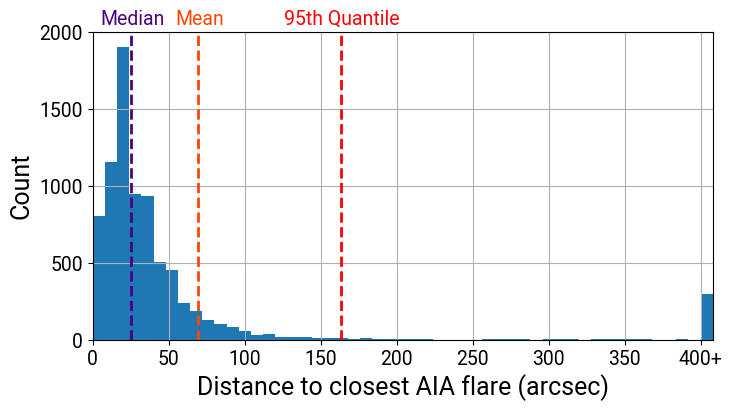

In [91]:
%matplotlib inline


import matplotlib.pyplot as plt
plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 10,
          'legend.handlelength': 3, 'figure.figsize':(8,4), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"



gaf = goes_fl.copy()
gaf['mindist'] = gaf[['ssw_dist','fd_dist']].min(axis=1)
gaf2 = gaf[ (~pd.isna(gaf['ssw_dist'])) & (~pd.isna(gaf['fd_dist'])) ]

avg = gaf2['mindist'].mean()
print(avg)
median = gaf2['mindist'].median()
print(median)
q95 = gaf2['mindist'].quantile(0.95)
print(q95)

binwidth = 8
# fig = matplotlib.pyplot.gcf()
# fig.set_size_inches(9, 6)
mybins = np.arange(min(gaf2['mindist']), 400 + binwidth, binwidth)

mybins = np.append(mybins, max(gaf2['mindist']))
ax = gaf2['mindist'].hist(bins=mybins)
ax.set_xlim(0, 408)
xlabels = np.array([0, 50, 100, 150, 200, 250, 300, 350, '400+'])
ax.set_xticklabels(xlabels)
ax.set_ylabel('Count',  fontproperties=font_prop)
ax.set_xlabel('Distance to closest AIA flare (arcsec)',  fontproperties=font_prop)

style = dict(size=14, color='indigo')
plt.text(26.31, 2050, "Median", ha='center', **style)

style = dict(size=14, color='orangered')
plt.text(70.37, 2050, "Mean", ha='center', **style)

style = dict(size=14, color='r')
plt.text(164.18, 2050, "95th Quantile", ha='center', **style)

plt.axvline(median, color='indigo', linestyle='dashed', linewidth=2)
plt.axvline(avg, color='orangered', linestyle='dashed', linewidth=2)
# plt.axvline(avg+2*stddev, color='g', linestyle='dashed', linewidth=1)
plt.axvline(q95, color='r', linestyle='dashed', linewidth=2)

mytitle = "outlier"
plt.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=1600)

# ax.set_title('Minimum AIA flare distance\n(valid SSW and Flare Detective)')

59.7706496244
172.023385619
127.11606964


Text(0.5,1,'Minimum AIA flare distance\n(valid SSW and Flare Detective)')

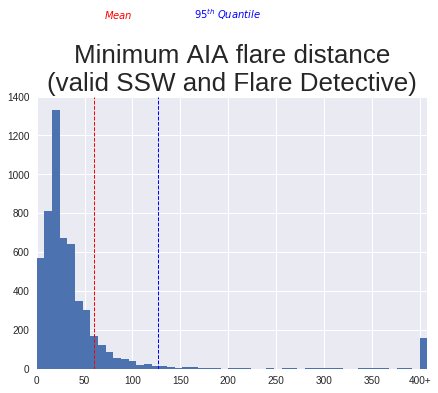

In [630]:
%matplotlib inline

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
# this is only C and above class flares.
gaf = goes_fl[ goes_fl['goes_class'] > 'C' ].copy()
gaf['mindist'] = gaf[['ssw_dist','fd_dist']].min(axis=1)
gaf2 = gaf[ (~pd.isna(gaf['ssw_dist'])) & (~pd.isna(gaf['fd_dist'])) ]

avg = gaf2['mindist'].mean()
print avg
stddev = gaf2['mindist'].std()
print stddev
q95 = gaf2['mindist'].quantile(0.95)
print q95

binwidth = 8
# fig = matplotlib.pyplot.gcf()
# fig.set_size_inches(9, 6)
mybins = np.arange(min(gaf2['mindist']), 400 + binwidth, binwidth)

mybins = np.append(mybins, max(gaf2['mindist']))
ax = gaf2['mindist'].hist(bins=mybins, ax=ax)
ax.set_xlim(0, 408)
xlabels = np.array([0, 50, 100, 150, 200, 250, 300, 350, '400+'])
ax.set_xticklabels(xlabels)

style = dict(size=10, color='red')
plt.text(70, 1800, "$Mean$", ha='left', **style)

style = dict(size=10, color='blue')
plt.text(164, 1800, "$95^{th}\;Quantile$", ha='left', **style)


plt.axvline(avg, color='r', linestyle='dashed', linewidth=1)
# plt.axvline(avg+2*stddev, color='g', linestyle='dashed', linewidth=1)
plt.axvline(q95, color='b', linestyle='dashed', linewidth=1)
ax.set_title('Minimum AIA flare distance\n(valid SSW and Flare Detective)')

Number of SSW filtered 3613
Number of GOES flares after SSW filter 8409


In [94]:
threshold = 163.18
ssw_filtered = goes_fl[ (pd.isna(goes_fl['ssw_dist'])) | (goes_fl['ssw_dist'] > threshold) ]
gff = goes_fl[ ~(pd.isna(goes_fl['ssw_dist'])) & (goes_fl['ssw_dist'] <= threshold) ]
print( 'Number of SSW filtered',ssw_filtered.shape[0])
print( 'Number of GOES flares after SSW filter',gff.shape[0])


fd_filtered = ssw_filtered[~(ssw_filtered['fd_dist'] < threshold)]
fd_found = ssw_filtered[ ssw_filtered['fd_dist'] < threshold ]
print( 'Number of FD and SSW filtered (invalidated)',fd_filtered.shape[0])
print( 'Filtered M', fd_filtered[fd_filtered['goes_class'] > 'M'].shape[0])
print( 'Filtered C', fd_filtered[fd_filtered['goes_class'].str.startswith('C')].shape[0])
print( 'Filtered B', fd_filtered[fd_filtered['goes_class'].str.startswith('B')].shape[0])
print( 'Filtered A', fd_filtered[fd_filtered['goes_class'].str.startswith('A')].shape[0])

goes_aia_v = pd.concat( [gff, fd_found], axis=0)
print( 'Total number of GOES flares validated after both AIA filters',goes_aia_v.shape[0])
print( 'Validated X', goes_aia_v[goes_aia_v['goes_class'].str.startswith('X')].shape[0])
print( 'Validated M', goes_aia_v[goes_aia_v['goes_class'].str.startswith('M')].shape[0])
print( 'Validated C', goes_aia_v[goes_aia_v['goes_class'].str.startswith('C')].shape[0])
print( 'Validated B', goes_aia_v[goes_aia_v['goes_class'].str.startswith('B')].shape[0])
print( 'Validated A', goes_aia_v[goes_aia_v['goes_class'].str.startswith('A')].shape[0])

# goes_aia_v.to_csv('goes_aia_validated.csv')
# fd_filtered.to_csv('aia_invalidated_goes_flares.csv')

Number of SSW filtered 3617
Number of GOES flares after SSW filter 8405
Number of FD and SSW filtered (invalidated) 1148
Filtered M 14
Filtered C 524
Filtered B 608
Filtered A 2
Total number of GOES flares validated after both AIA filters 10874
Validated X 50
Validated M 694
Validated C 6319
Validated B 3807
Validated A 4


In [60]:
# plt.rcParams.keys()

/home/baydin2/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


<Figure size 900x600 with 0 Axes>

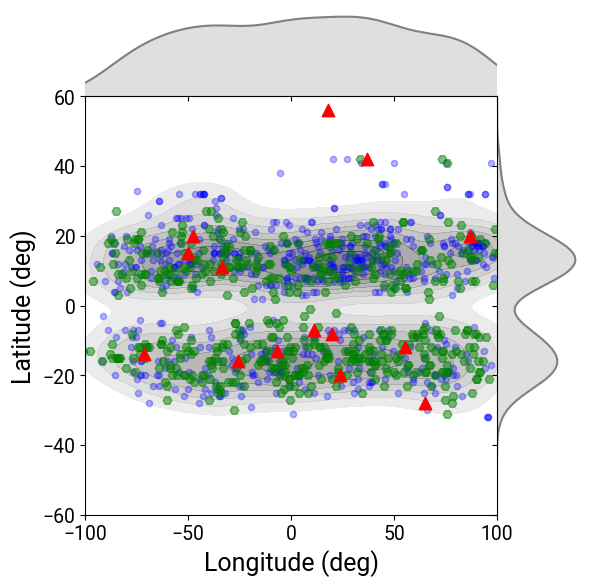

In [99]:
# fd_filtered[fd_filtered['goes_class'] < 'X']

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 10,
          'legend.handlelength': 3, 'figure.figsize':(8,4), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(9, 6)

# print(goes_lf.shape[0])
_plotter = fd_filtered.copy()

_plotter['class'] = _plotter['goes_class'].str[:1] 
x_loc = pd.to_numeric(_plotter['fl_lon'])
y_loc = pd.to_numeric(_plotter['fl_lat'])

_plotterB = _plotter[_plotter['class'] == 'B']
_plotterC = _plotter[_plotter['class'] == 'C']
_plotterM = _plotter[_plotter['class'] == 'M']


# _plotter_2011['x_loc'] = x_loc
# _plotter_2011['y_loc'] = y_loc
# print _plotter_2011.shape[0]

# with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
g = sns.jointplot(x="fl_lon", y="fl_lat", data=_plotter, space=0, color='grey', alpha=0.5, kind="kde")
current_palette_4 = sns.color_palette("cubehelix", 12)
sns.set_palette(current_palette_4)

g.x = _plotterB.fl_lon
g.y = _plotterB.fl_lat
g.plot_joint(plt.scatter, marker='o', c='b', alpha=0.3, s=20)

g.x = _plotterC.fl_lon
g.y = _plotterC.fl_lat
g.plot_joint(plt.scatter, marker='H', c='g', alpha=0.5, s=40)

g.x = _plotterM.fl_lon
g.y = _plotterM.fl_lat
g.plot_joint(plt.scatter, marker='^', c='r', s=80)

#     g.x = _plotterB.fl_lon
#     g.y = _plotterB.fl_lat
#     g.plot_joint(plt.scatter, marker='x', c='b', s=50)



#     g.plot_joint(plt.scatter, c="red", s=10, linewidth=2, alpha=0.4, marker="x")
g.ax_joint.collections[0].set_alpha(0.0)
# g.set_axis_labels("Longitude (deg)", "Latitude (deg)")
plt.ylabel("Latitude (deg)", fontproperties=font_prop)
plt.xlabel("Longitude (deg)", fontproperties=font_prop)


g.fig.axes[0].set(xlim=(-100, 100))
g.fig.axes[0].set(ylim=(-60, 60))

#     g.fig.set_figwidth(12)
#     g.fig.set_figheight(12)
#     sns.rugplot(x_loc, ax=g.fig.axes[0])
#     sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);
mytitle = "AIA-invalidated GOES flares (all)" 
#     g.fig.suptitle(mytitle)

g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)
g.fig.savefig(mytitle + '.png',  bbox_inches='tight', dpi=g.fig.dpi)



<Figure size 1200x600 with 0 Axes>

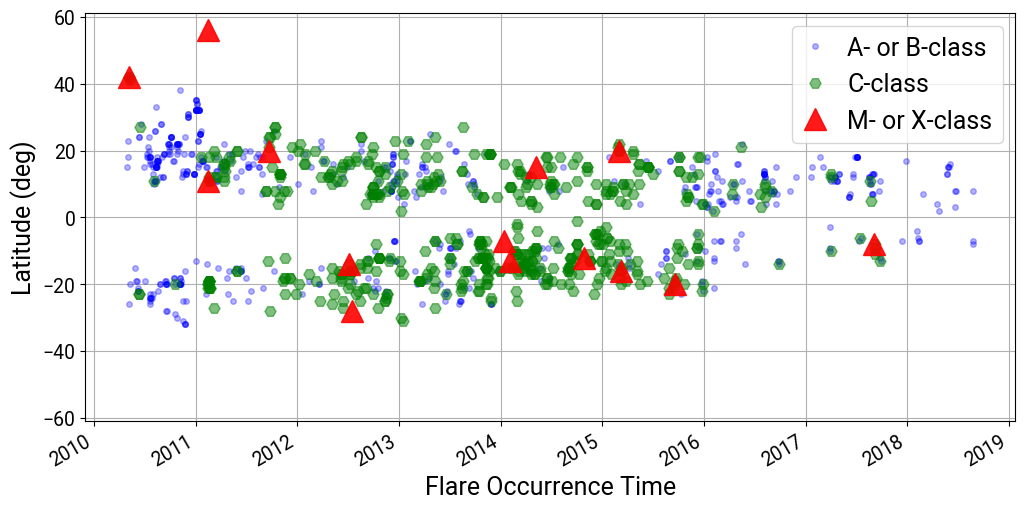

In [109]:


_plotter = fd_filtered.copy()
_plotter['class'] = _plotter['goes_class'].str[:1] 
_plotterM = _plotter[ _plotter['goes_class']>'M']
_plotterC = _plotter[ _plotter['class']=='C']
_plotterB = _plotter[ _plotter['goes_class']<'C']

plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 8,
          'legend.handlelength': 1, 'figure.figsize':(12,6), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"


# params = {'figure.figsize':(12,6)}
plt.rcParams.update(params)

fig = plt.figure()

ax = _plotterB.plot(x='peak_time', y='fl_lat', style="o", markersize=4, c='b', alpha=0.3)
ax = _plotterC.plot(x='peak_time', y='fl_lat', style="H", markersize=8, c='g', alpha=0.5, ax=ax)
ax = _plotterM.plot(x='peak_time', y='fl_lat', style="^", markersize=16, c='r', alpha=0.9, ax=ax)
ax.set_ylim(-61, 61)

ax.legend(["A- or B-class", "C-class", 'M- or X-class'], prop={'size': 18})
# ax.legend();
plt.grid()


# ax.set_ylabel("Latitude (deg)")

plt.xlabel('Flare Occurrence Time' , fontproperties=font_prop)
plt.ylabel("Latitude (deg)" , fontproperties=font_prop)

# ax.set_xlabel("Flare Occurrence Time")
mytitle = "Latitudes of AIA-invalidated flares" 
# ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)
fig.savefig(mytitle + '.png',  bbox_inches='tight', dpi=fig.dpi)

In [593]:
# avg = gaf2['ssw_dist'].mean()
# print avg
# stddev = gaf2['ssw_dist'].std()
# print stddev
# q95 = gaf2['ssw_dist'].quantile(0.95)
# print q95

# fig = matplotlib.pyplot.gcf()
# fig.set_size_inches(8, 8)
# ax = gaf2['ssw_dist'].hist(bins=250)
# plt.axvline(avg, color='r', linestyle='dashed', linewidth=1)
# plt.axvline(avg+2*stddev, color='g', linestyle='dashed', linewidth=1)
# plt.axvline(avg+2*stddev, color='g', linestyle='dashed', linewidth=1)
# plt.axvline(q95, color='b', linestyle='dashed', linewidth=1)
# ax.set_title('Distribution of distances for SSW distance\nred: mean, blue: 95th quantile, green: mean+two std dev')

# avg = gaf2['fd_dist'].mean()
# print avg
# stddev = gaf2['fd_dist'].std()
# print stddev
# q95 = gaf2['fd_dist'].quantile(0.95)
# print q95

# fig = matplotlib.pyplot.gcf()
# fig.set_size_inches(8, 8)
# ax = gaf2['fd_dist'].hist(bins=250)
# plt.axvline(avg, color='r', linestyle='dashed', linewidth=1)
# plt.axvline(avg+2*stddev, color='g', linestyle='dashed', linewidth=1)
# plt.axvline(avg+2*stddev, color='g', linestyle='dashed', linewidth=1)
# plt.axvline(q95, color='b', linestyle='dashed', linewidth=1)
# ax.set_title('Distribution of distances for FLDetective\nred: mean, blue: 95th quantile, green: mean+two std dev')

In [597]:
goes_aia_v[['goes_class', 'noaa_active_region']].shape[0]
goes_lf = goes_aia_v

In [60]:
import pandas as pd
# goes_aia_v = pd.read_csv('goes_aia_validated.csv')
goes_aia_v = get_goes_flare_dataframe('goes_aia_validated.csv')
goes_lf = goes_aia_v
goes_lf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10874 entries, 0 to 10873
Data columns (total 18 columns):
flare_id              10874 non-null int64
end_time              10874 non-null datetime64[ns]
event_date            10874 non-null object
goes_class            10874 non-null object
goes_location         10874 non-null object
noaa_active_region    10874 non-null int64
peak_time             10874 non-null datetime64[ns]
start_time            10874 non-null datetime64[ns]
fl_location           10874 non-null object
fl_lat                10874 non-null int64
fl_lon                10874 non-null float64
y                     10874 non-null float64
x                     10874 non-null float64
centroids             10807 non-null object
x_hpc                 10874 non-null float64
y_hpc                 10874 non-null float64
ssw_dist              8838 non-null float64
fd_dist               9702 non-null float64
dtypes: datetime64[ns](3), float64(7), int64(3), object(5)
memory usage: 

10874


/home/baydin2/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


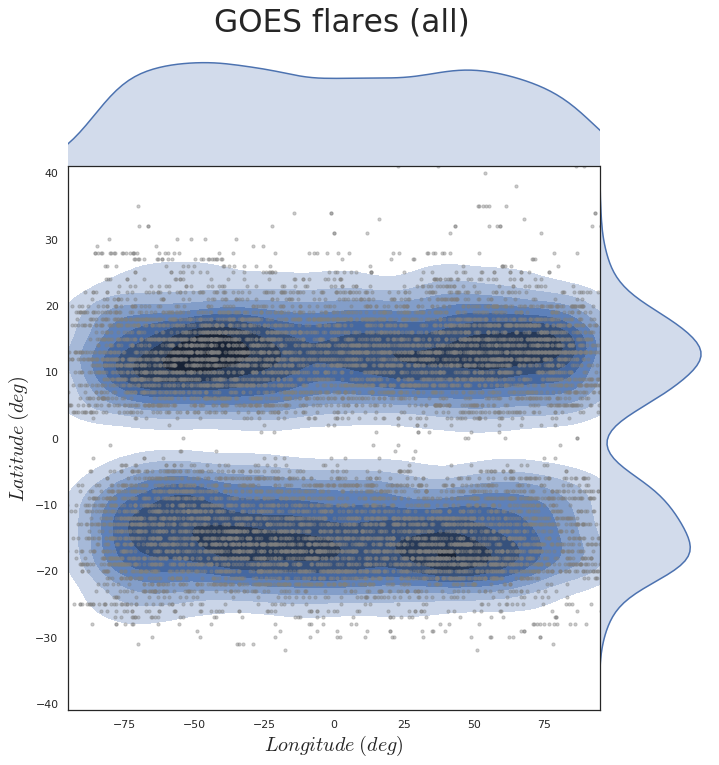

In [30]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('bmh')

# sns.set(rc={'figure.figsize':(16,12), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})

print(goes_lf.shape[0])
_plotter = goes_lf.copy()

_plotter['class'] = _plotter['goes_class'].str[:1] 

x_loc = pd.to_numeric(_plotter['fl_lon'])
y_loc = pd.to_numeric(_plotter['fl_lat'])
# _plotter_2011['x_loc'] = x_loc
# _plotter_2011['y_loc'] = y_loc
# print _plotter_2011.shape[0]

with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
    g = sns.jointplot(x="fl_lon", y="fl_lat", data=_plotter, space=0, kind="kde")
    current_palette_4 = sns.color_palette("cubehelix", 7)
    sns.set_palette(current_palette_4)
    
    g.plot_joint(plt.scatter, c="gray", s=10, linewidth=1, alpha=0.4, marker="o")
    g.ax_joint.collections[0].set_alpha(0.0)
    g.set_axis_labels("$Longitude\;(deg)$", "$Latitude\;(deg)$");
    g.fig.axes[0].set(xlim=(-95, 95))
    g.fig.axes[0].set(ylim=(-41, 41))

    g.fig.set_figwidth(12)
    g.fig.set_figheight(12)
#     sns.rugplot(x_loc, ax=g.fig.axes[0])
#     sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);
    mytitle = "GOES flares (all)" 
    g.fig.suptitle(mytitle)
    
    g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)
    g.fig.savefig(mytitle + '.png',  bbox_inches='tight', dpi=g.fig.dpi)



10874


/home/baydin2/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


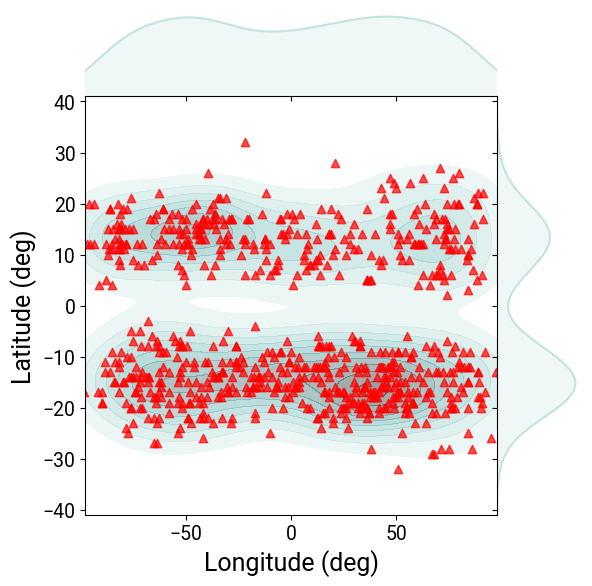

<Figure size 600x600 with 0 Axes>

In [66]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 10,
          'legend.handlelength': 3, 'figure.figsize':(8,4), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"


print(goes_lf.shape[0])
_plotter = goes_lf.copy()

_plotter['class'] = _plotter['goes_class'].str[:1] 
_plotter = _plotter[ _plotter['goes_class']>'M']
x_loc = pd.to_numeric(_plotter['fl_lon'])
y_loc = pd.to_numeric(_plotter['fl_lat'])
# _plotter_2011['x_loc'] = x_loc
# _plotter_2011['y_loc'] = y_loc
# print _plotter_2011.shape[0]

# with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
current_palette_4 = sns.cubehelix_palette(7, start=.5, rot=+.75)
sns.set_palette(current_palette_4)
g = sns.jointplot(x="fl_lon", y="fl_lat", data=_plotter, space=0, alpha=0.4, kind="kde")


g.plot_joint(plt.scatter, c="r", s=36, linewidth=1, alpha=0.7, marker="^")
g.ax_joint.collections[0].set_alpha(0.0)
# g.set_axis_labels("Longitude ($deg$)", "Latitude ($deg$)");

plt.xlabel("Longitude (deg)", fontproperties=font_prop)
plt.ylabel("Latitude (deg)", fontproperties=font_prop)

g.fig.axes[0].set(xlim=(-98, 98))
g.fig.axes[0].set(ylim=(-41, 41))

# g.fig.set_figwidth(12)
# g.fig.set_figheight(12)
plt.figure(figsize=(6,6))

#     sns.rugplot(x_loc, ax=g.fig.axes[0])
#     sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);
mytitle = "M- or X-class flares" 
#     g.fig.suptitle(mytitle)

g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)
g.fig.savefig(mytitle + '.png',  bbox_inches='tight', dpi=g.fig.dpi)


10874


/home/baydin2/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


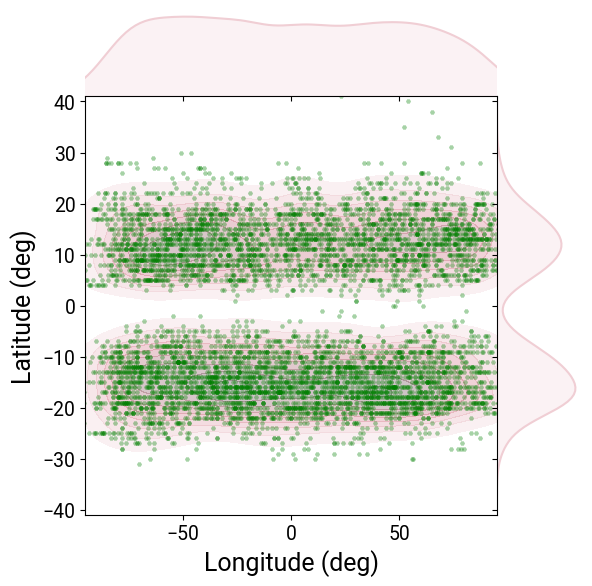

<Figure size 600x600 with 0 Axes>

In [67]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 10,
          'legend.handlelength': 3, 'figure.figsize':(8,4), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"

print(goes_lf.shape[0])
_plotter = goes_lf.copy()

_plotter['class'] = _plotter['goes_class'].str[:1] 
_plotter = _plotter[ _plotter['class']=='C']

# with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
current_palette_4 = sns.cubehelix_palette(7, start=.2, rot=+.25)
sns.set_palette(current_palette_4)
g = sns.jointplot(x="fl_lon", y="fl_lat", data=_plotter, space=0, alpha=0.25, kind="kde")

#     style="H", markersize=8, c='g'

g.plot_joint(plt.scatter, c="g", s=12, linewidth=0.1, alpha=0.35, marker="H")
g.ax_joint.collections[0].set_alpha(0.0)
# g.set_axis_labels("Longitude ($deg$)", "Latitude ($deg$)");
plt.xlabel("Longitude (deg)", fontproperties=font_prop)
plt.ylabel("Latitude (deg)", fontproperties=font_prop)

g.fig.axes[0].set(xlim=(-95, 95))
g.fig.axes[0].set(ylim=(-41, 41))
# g.fig.set_figwidth(12)
# g.fig.set_figheight(12)
plt.figure(figsize=(6,6))

mytitle = "C-class flares" 
#     g.fig.suptitle(mytitle)

g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)
g.fig.savefig(mytitle + '.png',  bbox_inches='tight', dpi=g.fig.dpi)



10874


/home/baydin2/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


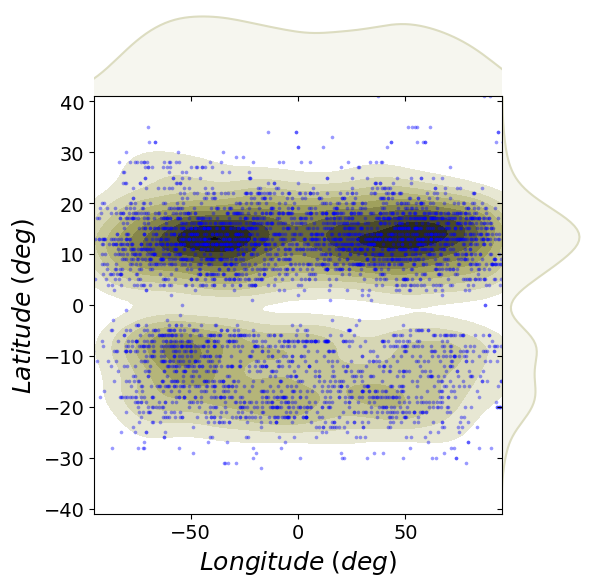

In [87]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')
from matplotlib import rc
# import matplotlib.font_manager
# print(matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'))
# plt.rcParams["font.family"] = "Roboto"
params = { 'font.family':'sans-serif', #'font.sans-serif':'Roboto-Black', 
          'legend.fontsize': 10,
          'legend.handlelength': 0, 'figure.figsize':(6,6), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)


print(goes_lf.shape[0])
_plotter = goes_lf.copy()

_plotter['class'] = _plotter['goes_class'].str[:1] 
_plotter = _plotter[ _plotter['goes_class']<'C']

# with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
current_palette_4 = sns.cubehelix_palette(3, start=.2, rot=+.5)
sns.set_palette(current_palette_4)
g = sns.jointplot(x="fl_lon", y="fl_lat", data=_plotter, space=0, kind="kde")


g.plot_joint(plt.scatter, c="b", s=6, linewidth=0.1, alpha=0.4, marker="o")
g.ax_joint.collections[0].set_alpha(0.0)
g.set_axis_labels("$Longitude\;(deg)$", "$Latitude\;(deg)$");
g.fig.axes[0].set(xlim=(-95, 95))
g.fig.axes[0].set(ylim=(-41, 41))
g.fig.set_figwidth(6)
g.fig.set_figheight(6)
mytitle = "A- or B-class flares" 
# g.fig.suptitle(mytitle)

g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)



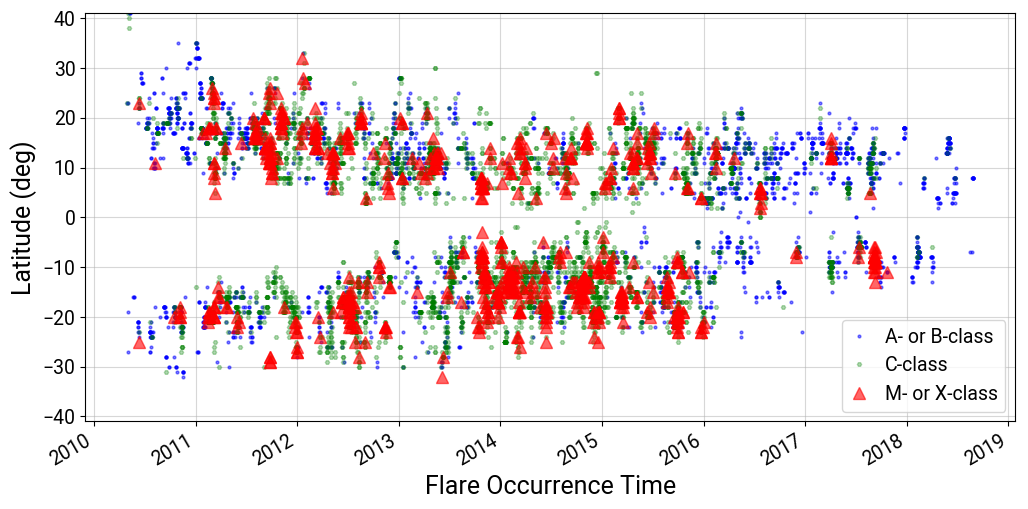

In [75]:


_plotter = goes_lf.copy()
_plotter['class'] = _plotter['goes_class'].str[:1] 
_plotterM = _plotter[ _plotter['goes_class']>'M']
_plotterC = _plotter[ _plotter['class']=='C']
_plotterB = _plotter[ _plotter['goes_class']<'C']

plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 9,
          'legend.handlelength': 1, 'figure.figsize':(12,6), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"

plt.rcParams['grid.alpha'] = 0.5


# fig = plt.figure()

ax = _plotterB.plot(x='peak_time', y='fl_lat', style="o", markersize=2, c='b', alpha=0.5)
ax = _plotterC.plot(x='peak_time', y='fl_lat', style="H", markersize=3, c='g', alpha=0.3, ax=ax)
ax = _plotterM.plot(x='peak_time', y='fl_lat', style="^", markersize=9, c='r', alpha=0.6, ax=ax)
ax.set_ylim(-41, 41)

ax.legend(["A- or B-class", "C-class", 'M- or X-class'], loc = 4, prop={'size': 14})
# ax.legend();



# ax.set_ylabel("Latitude (deg)")
ax.grid()

plt.xlabel('Flare Occurrence Time', fontproperties=font_prop)
plt.ylabel("Latitude (deg)", fontproperties=font_prop)

# ax.set_xlabel("Flare Occurrence Time")
mytitle = "Latitudes of flares" 
# ax.set_title(mytitle)
# params = { 'font.family':'sans-serif', #'font.sans-serif':'Roboto-Black', 
#           'legend.fontsize': 10,
#           'legend.handlelength': 0, 'figure.figsize':(12,6), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
#             "ytick.labelsize": 14, "xtick.labelsize":14}
# plt.rcParams.update(params)
# plt.legend(loc=1, prop={'size': 6})


fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)
fig.savefig(mytitle + '.png',  bbox_inches='tight', dpi=fig.dpi)

In [108]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('bmh')
# plt.rcParams["figure.figsize"] = (16,7)
# plt.rcParams.update({'font.size': 20})
# plt.rc('xtick', labelsize=20)
# plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 0, 'figure.figsize':(16,9), "font.size":12,"axes.titlesize":30,"axes.labelsize":30, 
            "ytick.labelsize": 24, "xtick.labelsize":24}
plt.rcParams.update(params)

# sns.set(rc={'figure.figsize':(7,7), "font.size":16,"axes.titlesize":26,"axes.labelsize":20})

goes_flare_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/goes_fl_no_loc.csv'
goes_fl_no_loc = get_goes_flare_dataframe(goes_flare_path)
print(goes_fl_no_loc.head())
aia_invalid_fl = goes_fl[~goes_fl['Unnamed: 0'].isin(goes_lf['Unnamed: 0'])]

aia_invalid_fl_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/aia_invalidated_goes_flares.csv'
aia_invalid_fl = pd.read_csv(aia_invalid_fl_path)
aia_invalid_fl.drop('Unnamed: 0.1', axis=1, inplace=True)
# print(aia_invalid_fl.head())

no_loc_fl_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/goes_fl_no_loc.csv'
no_loc_fl = pd.read_csv(no_loc_fl_path)
# aia_invalid_fl.drop('Unnamed: 0.1', axis=1, inplace=True)
print(no_loc_fl.head())


disclaimed_fl = pd.concat([aia_invalid_fl, goes_fl_no_loc], axis=0).sort_values(['Unnamed: 0'], ascending=[True], inplace=False)
disclaimed_fl['is_no_loc'] = disclaimed_fl['centroids'] != disclaimed_fl['centroids']
disclaimed_fl['is_aia_invalid'] = disclaimed_fl['centroids'] == disclaimed_fl['centroids']

invalid_goes_fl = disclaimed_fl[['Unnamed: 0', 'peak_time','goes_class', 'fl_location', 'is_no_loc', 'is_aia_invalid']]
# invalid_goes_fl.to_csv('invalid_goes_fl.csv')



   Unnamed: 0            end_time  event_date goes_class goes_location  \
0           5 2010-05-02 15:20:00  2010-05-02       B1.1        (0, 0)   
1           6 2010-05-02 16:29:00  2010-05-02       B1.9        (0, 0)   
2           7 2010-05-02 18:10:00  2010-05-02       B1.2        (0, 0)   
3           8 2010-05-02 21:03:00  2010-05-02       B1.4        (0, 0)   
4           9 2010-05-02 21:58:00  2010-05-02       B1.5        (0, 0)   

   noaa_active_region           peak_time          start_time  fl_location  \
0                   0 2010-05-02 15:14:00 2010-05-02 15:09:00          NaN   
1                   0 2010-05-02 16:26:00 2010-05-02 16:22:00          NaN   
2                   0 2010-05-02 17:59:00 2010-05-02 17:55:00          NaN   
3                   0 2010-05-02 21:00:00 2010-05-02 20:55:00          NaN   
4                   0 2010-05-02 21:53:00 2010-05-02 21:42:00          NaN   

   fl_lat  fl_lon   y   x  centroids  
0     NaN     NaN NaN NaN        NaN  
1     Na

KeyError: 'Unnamed: 0'

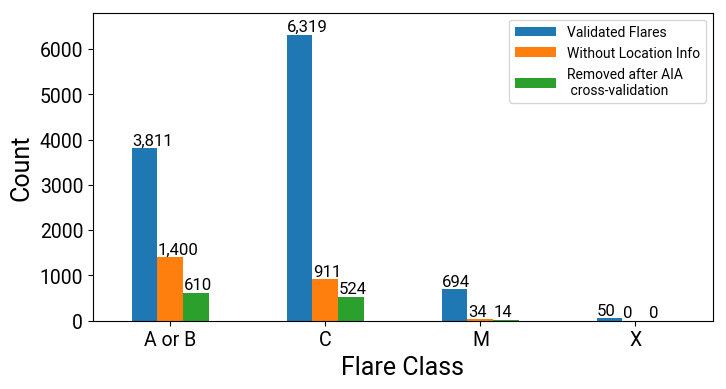

In [58]:
# invalid_goes_fl = pd.read_csv('invalid_goes_fl.csv')
# aia_v_fl = pd.read_csv('goes_aia_validated.csv')
# aia_v_fl.head()


# inv_large = invalid_goes_fl[invalid_goes_fl['goes_class']>'M'] #.str.startswith('B')]
# print('O.2 X final', aia_v_fl[aia_v_fl['goes_class'].str.startswith('X')].shape[0])
# print('O.2 M final', aia_v_fl[aia_v_fl['goes_class'].str.startswith('M')].shape[0])
# print('O.2 M no loc', no_loc_fl[no_loc_fl['goes_class'] > 'M'].shape[0])
# print('O.2 M aia inv', aia_invalid_fl[aia_invalid_fl['goes_class']>'M'].shape[0])

# C = invalid_goes_fl[invalid_goes_fl['goes_class'].str.startswith('C')]
# print('O.2 C final', aia_v_fl[aia_v_fl['goes_class'].str.startswith('C')].shape[0])
# print('O.2 C no loc', no_loc_fl[no_loc_fl['goes_class'].str.startswith('C')].shape[0])
# print('O.2 C aia inv', aia_invalid_fl[aia_invalid_fl['goes_class'].str.startswith('C')].shape[0])

# B = invalid_goes_fl[invalid_goes_fl['goes_class']<'C'] #.str.startswith('B')]
# print('O.2 A|B final', aia_v_fl[aia_v_fl['goes_class']<'C'].shape[0])
# print('O.2 A|B no loc', no_loc_fl[no_loc_fl['goes_class'] < 'C'].shape[0])
# print('O.2 A|B aia inv', aia_invalid_fl[aia_invalid_fl['goes_class'] < 'C'].shape[0])

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
from matplotlib import rc
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(fname=font_path, weight='regular', size=18)

params = { #'font.family':'sans-serif', 'font.sans-serif':'Roboto-Regular', 
          'legend.fontsize': 10,
          'legend.handlelength': 3, 'figure.figsize':(8,4), "font.size":12,"axes.titlesize":22,"axes.labelsize":18, 
            "ytick.labelsize": 14, "xtick.labelsize":14}
plt.rcParams.update(params)
matplotlib.rcParams['font.sans-serif'] = 'roboto'
plt.rc('font', weight='regular')
matplotlib.rcParams['font.family'] = "sans-serif"

# print(plt.rcParams['font.sans-serif'])

df = pd.DataFrame(index=['A or B', 'C', 'M', 'X'], columns=['Validated Flares', 'Without Location Info', 'Removed after AIA\n cross-validation'], 
             data=[ [3811, 1400,610], [6319, 911,524], [694, 34,14], [50, 0, 0] ])
ax = df.plot(kind='bar')

for p in ax.patches: 
    ax.annotate("{:,}".format(np.round(p.get_height(),decimals=2)), (p.get_x()+p.get_width()/2., p.get_height()+21), 
                ha='left', va='center', rotation=0, xytext=(-9, 5), textcoords='offset points')
plt.xticks(rotation=0)

plt.xlabel("Flare Class", fontproperties=font_prop)
plt.ylabel("Count", fontproperties=font_prop)
fig = ax.get_figure()
fig.axes[0].set(ylim=(0, 6800))

mytitle = 'flarecounts'
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=False, dpi=fig.dpi)

In [40]:
import matplotlib.font_manager
matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
# plt.rc('font',family='Roboto')
# matplotlib.font_manager._rebuild()
matplotlib.font_manager.findfont('roboto')

'/usr/share/fonts/truetype/roboto/hinted/Roboto-Regular.ttf'

In [59]:
import matplotlib.font_manager
from IPython.core.display import HTML
def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

# HTML("<div style='column-count: 2;'>{}</div>".format(code))